In [185]:
CSV_FILE      = "ASIANPAINT.csv"
MODEL_TYPE    = "LSTM"
INPUT_STEPS   = 10
OUTPUT_STEPS  = 5
OVERLAP       = 5
TRAIN_RATIO   = 0.8
BATCH_SIZE    = 32
EPOCHS        = 50
PATIENCE      = 10
LR            = 0.001
HIDDEN_SIZE   = 64
NUM_LAYERS    = 2
DROPOUT       = 0.2

FEATURES = [
    'Prev Close', 'Open', 'High', 'Low', 'Last',
    'Close', 'VWAP', 'Volume', 'Turnover',
    'Trades', 'Deliverable Volume'
]

NUM_FEATURES = 11

In [186]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Path to dataset files: /kaggle/input/nifty50-stock-market-data


In [187]:
import os

os.listdir(path)

['HDFCBANK.csv',
 'GRASIM.csv',
 'WIPRO.csv',
 'stock_metadata.csv',
 'BPCL.csv',
 'INFY.csv',
 'LT.csv',
 'RELIANCE.csv',
 'BRITANNIA.csv',
 'INFRATEL.csv',
 'HEROMOTOCO.csv',
 'HINDUNILVR.csv',
 'TATAMOTORS.csv',
 'MM.csv',
 'HDFC.csv',
 'JSWSTEEL.csv',
 'TITAN.csv',
 'HINDALCO.csv',
 'AXISBANK.csv',
 'HCLTECH.csv',
 'ADANIPORTS.csv',
 'GAIL.csv',
 'NIFTY50_all.csv',
 'BAJAJFINSV.csv',
 'BAJFINANCE.csv',
 'ICICIBANK.csv',
 'ZEEL.csv',
 'ASIANPAINT.csv',
 'IOC.csv',
 'TATASTEEL.csv',
 'COALINDIA.csv',
 'NESTLEIND.csv',
 'DRREDDY.csv',
 'ONGC.csv',
 'EICHERMOT.csv',
 'UPL.csv',
 'SUNPHARMA.csv',
 'ULTRACEMCO.csv',
 'CIPLA.csv',
 'SHREECEM.csv',
 'VEDL.csv',
 'TCS.csv',
 'NTPC.csv',
 'MARUTI.csv',
 'KOTAKBANK.csv',
 'ITC.csv',
 'BAJAJ-AUTO.csv',
 'SBIN.csv',
 'INDUSINDBK.csv',
 'BHARTIARTL.csv',
 'TECHM.csv',
 'POWERGRID.csv']

## Part 1 — Import Libraries

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [189]:
import os

# Load ASIANPAINT.csv
df = pd.read_csv(os.path.join(path, CSV_FILE))

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (5306, 15)

Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

First 5 rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,ASIANPAINT,EQ,361.20,370.0,390.0,370.0,385.0,381.65,380.54,3318,1.262617e+11,NaN,NaN,NaN
1,2000-01-04,ASIANPAINT,EQ,381.65,380.0,392.0,375.0,390.0,385.55,383.50,4818,1.847699e+11,NaN,NaN,NaN
2,2000-01-05,ASIANPAINT,EQ,385.55,371.5,390.0,371.5,383.0,383.00,379.81,2628,9.981384e+10,NaN,NaN,NaN
3,2000-01-06,ASIANPAINT,EQ,383.00,384.9,384.9,374.5,375.1,377.50,379.88,3354,1.274114e+11,NaN,NaN,NaN
4,2000-01-07,ASIANPAINT,EQ,377.50,376.0,390.0,370.0,389.0,385.70,383.38,9589,3.676275e+11,NaN,NaN,NaN


In [158]:
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
%Deliverble            509
dtype: int64

Total missing values: 3868


In [177]:
print(" Check and Remove Duplicates")
dup_values = df.duplicated().sum()
print(f"Duplicate rows found: {dup_values}")
if dup_values > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

 Check and Remove Duplicates
Duplicate rows found: 0
No duplicates found.


In [192]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Invalid dates (NaT): {df['Date'].isnull().sum()}")

df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"\nAfter sorting by date: {df.shape}")

Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Invalid dates (NaT): 0

After sorting by date: (5306, 15)


In [191]:
available_features = [f for f in FEATURES if f in df.columns]

pct_cols = [c for c in df.columns if '%' in c.lower() or 'pct' in c.lower()]
available_features += pct_cols[:1] if 'Deliverable Volume' not in df.columns else []

available_features = list(dict.fromkeys(available_features))

df_feat = df[['Date'] + available_features].copy()

print(f"Features selected ({len(available_features)}):", available_features)
print(f"\nDataset shape: {df_feat.shape}")
df_feat.head()

Features selected (11): ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

Dataset shape: (5306, 12)


,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,2000-01-03,361.20,370.0,390.0,370.0,385.0,381.65,380.54,3318,1.262617e+11,NaN,NaN
1,2000-01-04,381.65,380.0,392.0,375.0,390.0,385.55,383.50,4818,1.847699e+11,NaN,NaN
2,2000-01-05,385.55,371.5,390.0,371.5,383.0,383.00,379.81,2628,9.981384e+10,NaN,NaN
3,2000-01-06,383.00,384.9,384.9,374.5,375.1,377.50,379.88,3354,1.274114e+11,NaN,NaN
4,2000-01-07,377.50,376.0,390.0,370.0,389.0,385.70,383.38,9589,3.676275e+11,NaN,NaN


In [190]:
print("Missing before interpolation:")
print(df_feat.isnull().sum())

df_feat[available_features] = df_feat[available_features].interpolate(
    method='linear', limit_direction='both'
)
df_feat[available_features] = df_feat[available_features].ffill().bfill()

print("\nMissing after interpolation:")
print(df_feat.isnull().sum())
print(f"\nFinal shape: {df_feat.shape}")

Missing before interpolation:
Date                  0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

Missing after interpolation:
Date                  0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

Final shape: (5306, 12)


In [193]:
print(df_feat.dtypes)

for col in available_features:
    df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')

df_feat[available_features] = df_feat[available_features].ffill().bfill()
print("\nAll feature columns converted to float.")
print(df_feat.dtypes)

Date                   object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
dtype: object

All feature columns converted to float.
Date                   object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
dtype: object


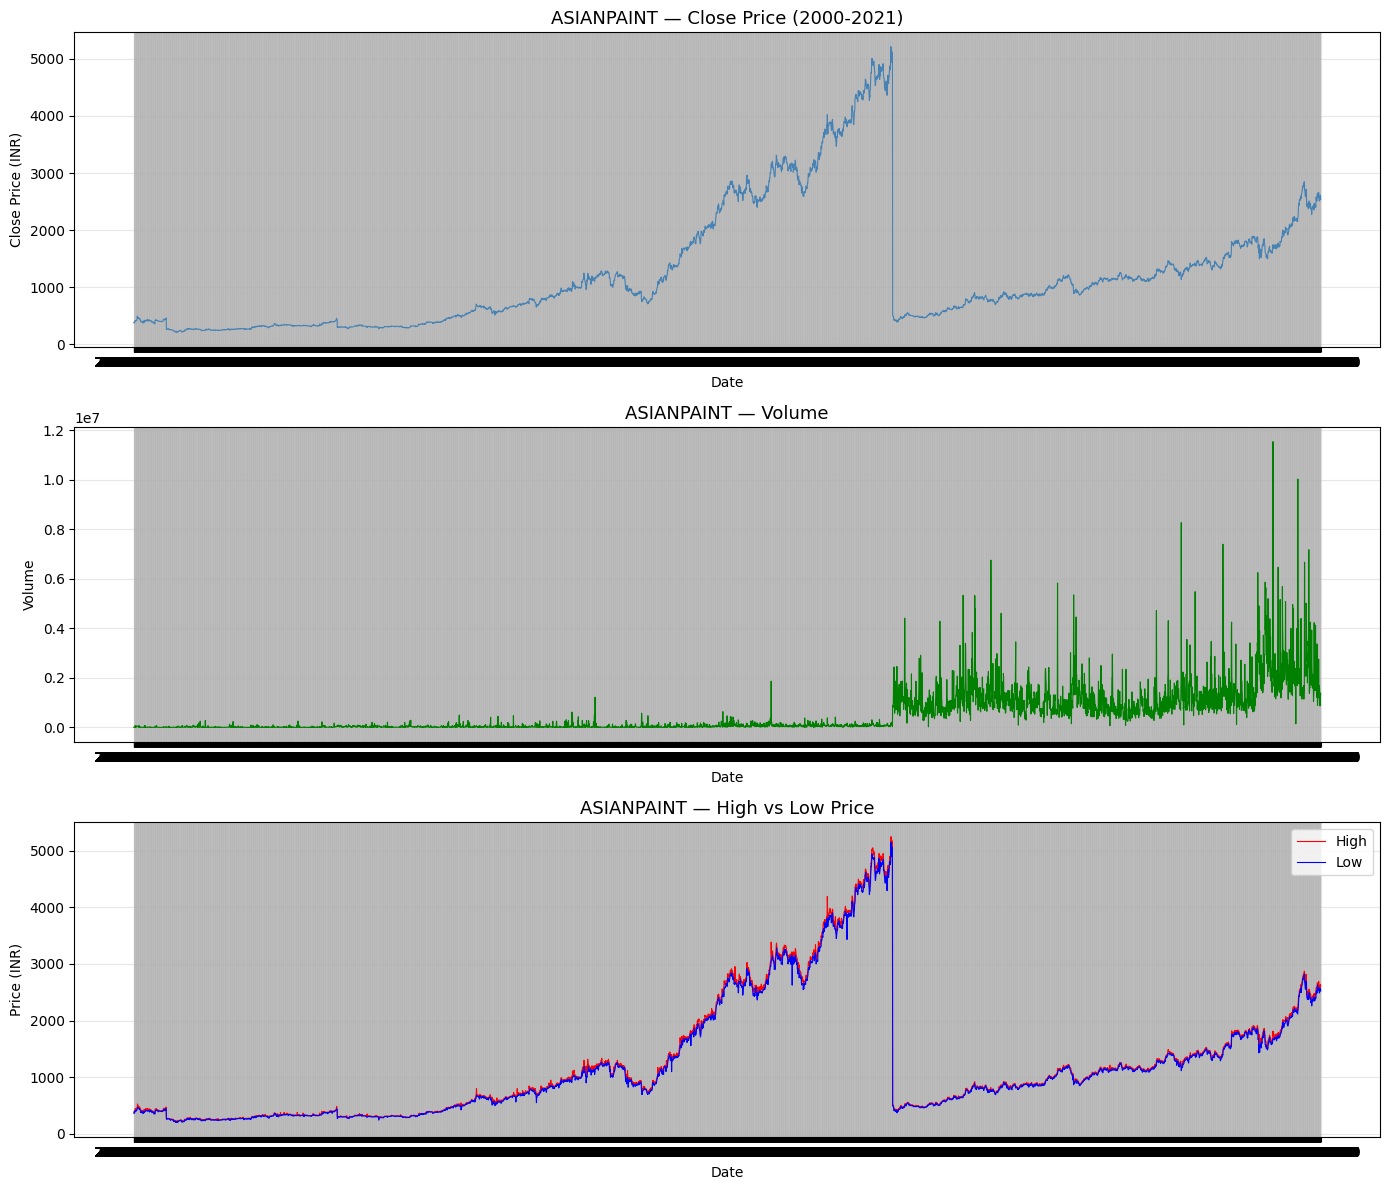

In [215]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df_feat['Date'], df_feat['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('ASIANPAINT — Close Price (2000-2021)', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Close Price (INR)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_feat['Date'], df_feat['Volume'], color='green', linewidth=0.8)
axes[1].set_title('ASIANPAINT — Volume', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_feat['Date'], df_feat['High'], color='red', linewidth=0.8, label='High')
axes[2].plot(df_feat['Date'], df_feat['Low'], color='blue', linewidth=0.8, label='Low')
axes[2].set_title('ASIANPAINT — High vs Low Price', fontsize=13)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (INR)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [195]:
dates     = df_feat['Date'].values
data_vals = df_feat[available_features].values.astype(np.float32)

NUM_FEATURES = data_vals.shape[1]
print(f"Actual number of features used: {NUM_FEATURES}")


split_idx  = int(len(data_vals) * TRAIN_RATIO)
train_data = data_vals[:split_idx]
test_data  = data_vals[split_idx:]
train_dates = dates[:split_idx]
test_dates  = dates[split_idx:]

print(f"Train: {train_data.shape}  ({train_dates[0]} to {train_dates[-1]})")
print(f"Test:  {test_data.shape}   ({test_dates[0]} to {test_dates[-1]})")

Actual number of features used: 11
Train: (4244, 11)  (2000-01-03 to 2017-01-12)
Test:  (1062, 11)   (2017-01-13 to 2021-04-30)


In [221]:
# L2 Normalization
train_norm = normalize(train_data, norm='l2', axis=0)
test_norm  = normalize(test_data,  norm='l2', axis=0)

In [197]:
def create_sequences(data, input_steps, output_steps, overlap):

    X, y = [], []
    stride = input_steps - overlap
    if stride <= 0:
        stride = 1

    for i in range(0, len(data) - input_steps - output_steps + 1, stride):
        X.append(data[i : i + input_steps])
        y.append(data[i + input_steps : i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_norm, INPUT_STEPS, OUTPUT_STEPS, OVERLAP)
X_test,  y_test  = create_sequences(test_norm,  INPUT_STEPS, OUTPUT_STEPS, OVERLAP)

print(f"Input steps:  {INPUT_STEPS} days | Output steps: {OUTPUT_STEPS} days | Overlap: {OVERLAP} days")
print(f"X_train: {X_train.shape}  → (samples, input_steps, features)")
print(f"y_train: {y_train.shape}  → (samples, output_steps, features)")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

Input steps:  10 days | Output steps: 5 days | Overlap: 5 days
X_train: (846, 10, 11)  → (samples, input_steps, features)
y_train: (846, 5, 11)  → (samples, output_steps, features)
X_test:  (210, 10, 11)
y_test:  (210, 5, 11)


In [198]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset  = StockDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Verify shape
for X_b, y_b in train_loader:
    print(f"Batch X shape: {X_b.shape}  → (batch, input_steps, features)")
    print(f"Batch y shape: {y_b.shape}  → (batch, output_steps, features)")
    break

Train batches: 27
Test  batches: 7
Batch X shape: torch.Size([32, 10, 11])  → (batch, input_steps, features)
Batch y shape: torch.Size([32, 5, 11])  → (batch, output_steps, features)


In [203]:
class StockForecaster(nn.Module):
    def __init__(self, model_type, input_size, hidden_size,
                 num_layers, output_steps, num_features, dropout):
        super(StockForecaster, self).__init__()

        self.model_type  = model_type
        self.output_steps = output_steps
        self.num_features = num_features
        self.rnn = nn.LSTM(
                input_size  = input_size,
                hidden_size = hidden_size,
                num_layers  = num_layers,
                batch_first = True,
                dropout     = dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_steps * num_features)

    def forward(self, x):
        out, (hn, cn) = self.rnn(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        out = out.view(-1, self.output_steps, self.num_features)
        return out

model = StockForecaster(
    model_type   = MODEL_TYPE,
    input_size   = NUM_FEATURES,
    hidden_size  = HIDDEN_SIZE,
    num_layers   = NUM_LAYERS,
    output_steps = OUTPUT_STEPS,
    num_features = NUM_FEATURES,
    dropout      = DROPOUT
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

StockForecaster(
  (rnn): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=55, bias=True)
)

Total trainable parameters: 56,567


In [214]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        preds = model(X_b)
        loss  = criterion(preds, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds     = model(X_b)
            loss      = criterion(preds, y_b)
            total_loss += loss.item() * X_b.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_b.cpu().numpy())
    avg_loss    = total_loss / len(loader.dataset)
    all_preds   = np.concatenate(all_preds,   axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    return avg_loss, all_preds, all_targets

#  Training Loop with Early Stopping
train_losses      = []
test_losses       = []
best_test_loss    = float('inf')
epochs_no_improve = 0

print(f"Training {MODEL_TYPE} model for up to {EPOCHS} epochs...")
print("-" * 70)

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    test_loss, preds, targets = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model_asianpaint.pt')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_asianpaint.pt'))
print(f"\nBest model loaded! Best Test Loss: {best_test_loss:.6f}")

Training LSTM model for up to 50 epochs...
----------------------------------------------------------------------
Epoch [  1/50] | Train Loss: 0.000029 | Test Loss: 0.000115
Epoch [  5/50] | Train Loss: 0.000026 | Test Loss: 0.000116
Epoch [ 10/50] | Train Loss: 0.000027 | Test Loss: 0.000122

Early stopping at epoch 14

Best model loaded! Best Test Loss: 0.000111


## Part 11 — Loss Curves

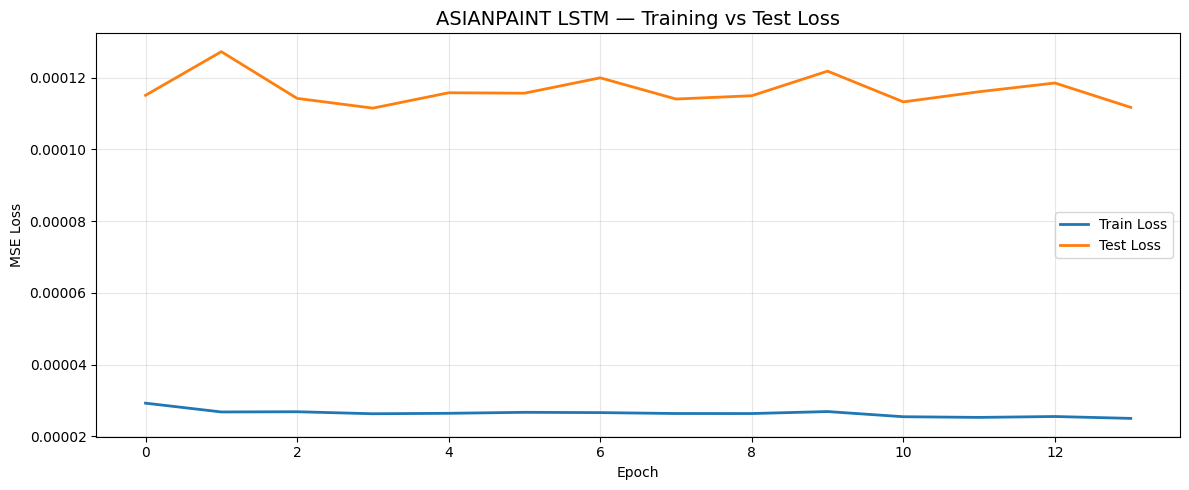

In [216]:
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  linewidth=2)
plt.title(f'ASIANPAINT {MODEL_TYPE} — Training vs Test Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 12 — Performance Metrics (MSE, RMSE, MAE)

In [217]:
_, final_preds, final_targets = evaluate(model, test_loader, criterion)

preds_flat   = final_preds.reshape(-1)
targets_flat = final_targets.reshape(-1)

mse  = mean_squared_error(targets_flat, preds_flat)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_flat, preds_flat)

print("=" * 50)
print(f"  MODEL    : {MODEL_TYPE}")
print(f"  DATASET  : ASIANPAINT.csv")
print(f"  INPUT    : {INPUT_STEPS} days → OUTPUT: {OUTPUT_STEPS} days")
print(f"  FEATURES : {NUM_FEATURES}")
print("=" * 50)
print(f"  MSE  (Mean Squared Error)       : {mse:.6f}")
print(f"  RMSE (Root Mean Squared Error)  : {rmse:.6f}")
print(f"  MAE  (Mean Absolute Error)      : {mae:.6f}")
print("=" * 50)

print("\nPer-Feature Metrics:")
print(f"{'Feature':<25} {'MSE':>12} {'RMSE':>12} {'MAE':>12}")
print("-" * 62)
for i, feat in enumerate(available_features):
    p = final_preds[:, :, i].reshape(-1)
    t = final_targets[:, :, i].reshape(-1)
    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)
    print(f"{feat:<25} {f_mse:>12.6f} {f_rmse:>12.6f} {f_mae:>12.6f}")

  MODEL    : LSTM
  DATASET  : ASIANPAINT.csv
  INPUT    : 10 days → OUTPUT: 5 days
  FEATURES : 11
  MSE  (Mean Squared Error)       : 0.000111
  RMSE (Root Mean Squared Error)  : 0.010559
  MAE  (Mean Absolute Error)      : 0.005901

Per-Feature Metrics:
Feature                            MSE         RMSE          MAE
--------------------------------------------------------------
Prev Close                    0.000017     0.004115     0.003082
Open                          0.000017     0.004105     0.003081
High                          0.000018     0.004233     0.003152
Low                           0.000017     0.004144     0.003112
Last                          0.000017     0.004175     0.003119
Close                         0.000018     0.004227     0.003181
VWAP                          0.000017     0.004119     0.003059
Volume                        0.000250     0.015812     0.009720
Turnover                      0.000312     0.017650     0.012795
Trades                        

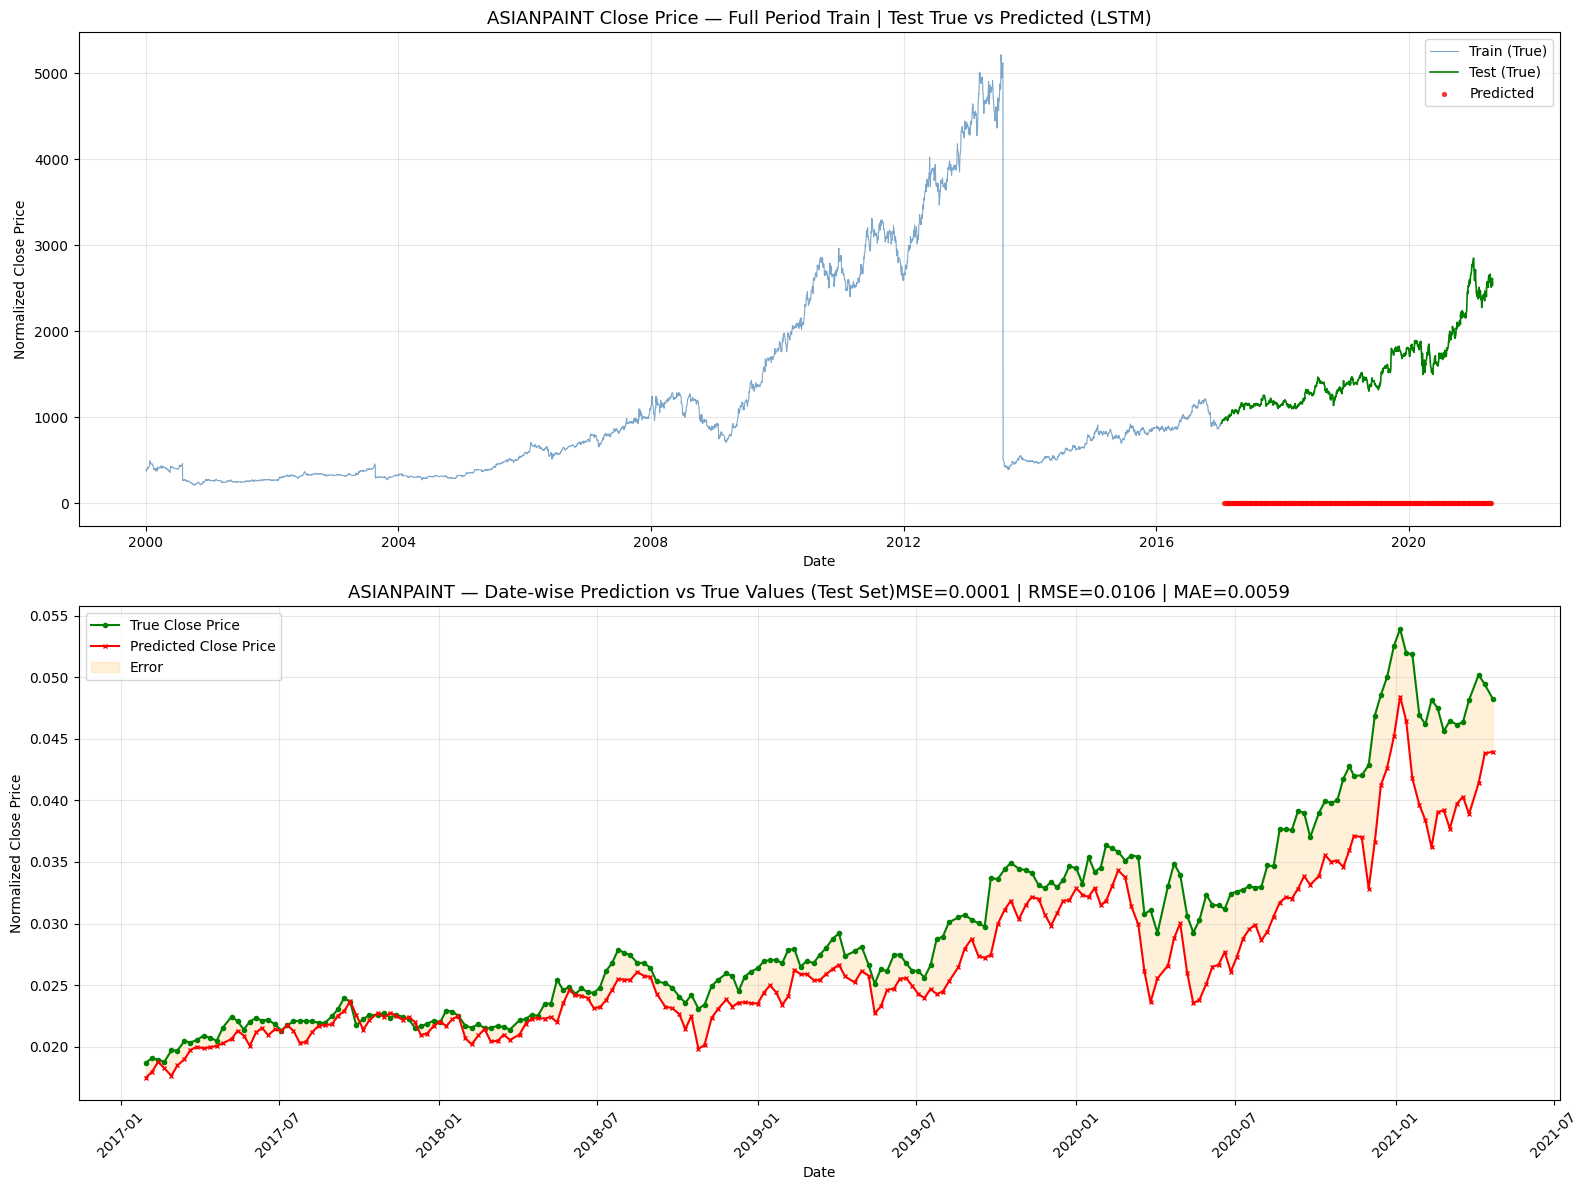

Plot saved as 'ASIANPAINT_predictions.png'


In [218]:
stride = INPUT_STEPS - OVERLAP if (INPUT_STEPS - OVERLAP) > 0 else 1
pred_start_indices = list(range(
    INPUT_STEPS,
    len(test_norm) - OUTPUT_STEPS + 1,
    stride
))[:len(final_preds)]

pred_dates = []
for idx in pred_start_indices:
    actual_idx = split_idx + idx
    if actual_idx < len(dates):
        pred_dates.append(pd.Timestamp(dates[actual_idx]))
    else:
        pred_dates.append(pd.Timestamp(dates[-1]))

pred_dates = pred_dates[:len(final_preds)]

close_idx = available_features.index('Close') if 'Close' in available_features else 5

pred_close = final_preds[:, 0, close_idx]
true_close = final_targets[:, 0, close_idx]

test_close_all  = test_data[:, close_idx]
test_dates_all  = pd.to_datetime(test_dates)
pred_dates_plot = pd.to_datetime(pred_dates[:len(pred_close)])

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

train_close = train_data[:, close_idx]
train_dates_plot = pd.to_datetime(train_dates)

axes[0].plot(train_dates_plot, train_close,
             color='steelblue', linewidth=0.8, label='Train (True)', alpha=0.7)
axes[0].plot(test_dates_all, test_close_all,
             color='green', linewidth=1.2, label='Test (True)')
axes[0].scatter(pred_dates_plot, pred_close,
                color='red', s=8, label='Predicted', zorder=5, alpha=0.7)
axes[0].set_title(f'ASIANPAINT Close Price — Full Period Train | Test True vs Predicted ({MODEL_TYPE})',fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Close Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(pred_dates_plot, true_close,
             color='green', linewidth=1.5, marker='o', markersize=3,
             label='True Close Price')
axes[1].plot(pred_dates_plot, pred_close,
             color='red', linewidth=1.5, marker='x', markersize=3,
             label='Predicted Close Price')
axes[1].fill_between(pred_dates_plot,
                     true_close, pred_close,
                     alpha=0.15, color='orange', label='Error')
axes[1].set_title(f'ASIANPAINT — Date-wise Prediction vs True Values (Test Set)'f'MSE={mse:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}',fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Normalized Close Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('ASIANPAINT_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'ASIANPAINT_predictions.png'")

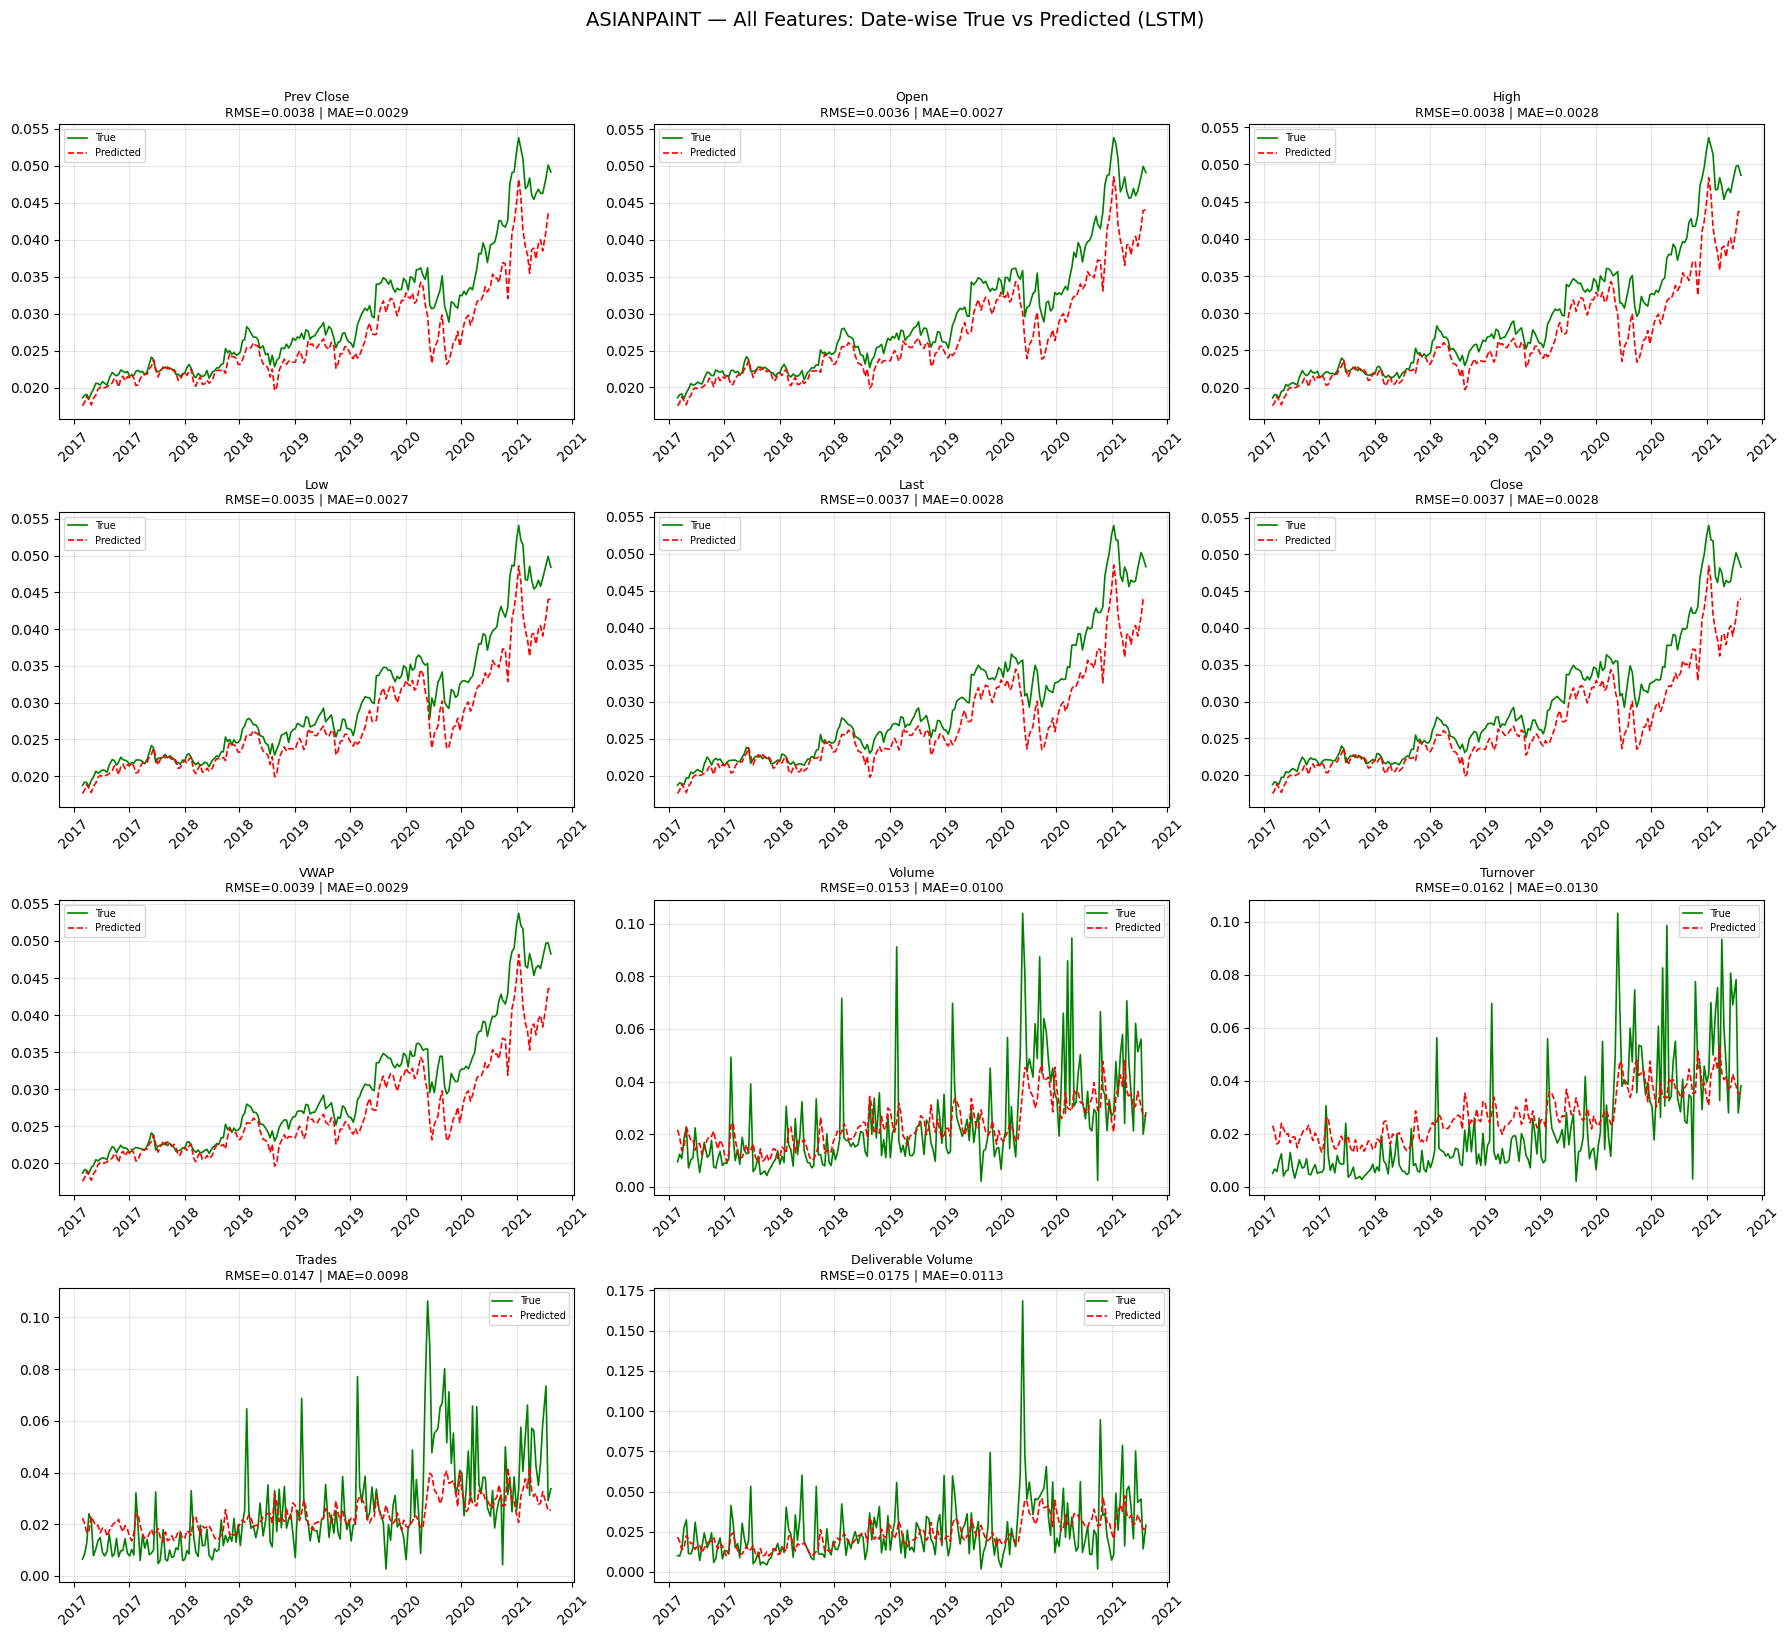

All-features plot saved!


In [219]:
n_feats = NUM_FEATURES
cols = 3
rows = (n_feats + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(available_features):
    p = final_preds[:, 0, i]
    t = final_targets[:, 0, i]

    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)

    ax = axes[i]
    ax.plot(pred_dates_plot[:len(t)], t,
            color='green', linewidth=1.2, label='True')
    ax.plot(pred_dates_plot[:len(p)], p,
            color='red',   linewidth=1.2, label='Predicted', linestyle='--')
    ax.set_title(f'{feat}\nRMSE={f_rmse:.4f} | MAE={f_mae:.4f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'ASIANPAINT — All Features: Date-wise True vs Predicted ({MODEL_TYPE})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ASIANPAINT_all_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("All-features plot saved!")

In [220]:
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE'],
    'Value':  [f"{mse:.6f}", f"{rmse:.6f}", f"{mae:.6f}"],
}
results_df = pd.DataFrame(metrics_data)
print(results_df.to_string(index=False))

Metric    Value
   MSE 0.000111
  RMSE 0.010559
   MAE 0.005901
